In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score

In [2]:
# Logistic Regression is a classification algorithm used when the output is binary (0 or 1).
# Why Not Linear Regression?
# Linear regression gives output like:
# 0.3, 1.7, -0.5
# But in classification we need:
# 0 or 1


# Sigmoid Function
# σ(z)=1/(1+(e^(-z)))
# It converts any value into a number between 0 and 1.


# What is Confusion Matrix?
# It compares Actual values vs Predicted values.
#         |          | Predicted 0 | Predicted 1 |
#         | -------- | ----------- | ----------- |
#         | Actual 0 | TN          | FP          |
#         | Actual 1 | FN          | TP          |
# Where:
# TP → True Positive
# TN → True Negative
# FP → False Positive
# FN → False Negative



# Accuracy = (TP+TN) / total
# Error = 1 − Accuracy
# Precision = TP / (TP+FP)
# Recall = TP / (TP+FN)


In [3]:
# load
df = pd.read_csv("Social_Network_Ads.csv")
df.dtypes
df


,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0
...,...,...,...
395,46,41000,1
396,51,23000,1
397,50,20000,1
398,36,33000,0


In [4]:
#  Features (Age and EstimatedSalary) and Target (Purchased)
X = df[['Age', 'EstimatedSalary']]
y = df['Purchased']
X

,Age,EstimatedSalary
0,19,19000
1,35,20000
2,26,43000
3,27,57000
4,19,76000
...,...,...
395,46,41000
396,51,23000
397,50,20000
398,36,33000


In [5]:
# Split into Train and Test Set
# from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25)
# X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=0)
X_train.shape
X_test.shape
y_train.shape
y_test.shape
X_train

# train_test_split
# - Randomly shuffles data
# - Splits into training and testing parts
# - Returns 4 outputs

# test_size=0.25  =>  
#     25% data → Testing
#     75% data → Training

# random_state=0   =>  
#         It controls randomness.
#         If removed:  Every time you run, data splits differently.

,Age,EstimatedSalary
344,47,105000
279,50,36000
53,35,23000
211,52,150000
369,54,26000
...,...,...
330,38,51000
359,42,54000
312,38,50000
131,33,31000


In [6]:
# Feature Scaling
# from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
print(X_train)
X_train = sc.fit_transform(X_train)
print(X_train)
print(X_test)
X_test = sc.transform(X_test)
print(X_test)
# X_train


# StandardScaler()
#     sc = StandardScaler()
# Creates a StandardScaler object
# This object stores mean and standard deviation of training data

# fit_transform(X_train)
#     X_train = sc.fit_transform(X_train)
# fit() → calculates mean (μ) and standard deviation (σ) from training data
# transform() → applies the standardization formula
# Both steps done together for training data
# Important: Training data is used to learn scaling parameters

# transform(X_test)
#     X_test = sc.transform(X_test)
# Uses same μ and σ from training data
# Prevents data leakage
# Ensures fair evaluations
# Important : Never use fit_transform() on test data

     Age  EstimatedSalary
344   47           105000
279   50            36000
53    35            23000
211   52           150000
369   54            26000
..   ...              ...
330   38            51000
359   42            54000
312   38            50000
131   33            31000
182   32           117000

[300 rows x 2 columns]
[[ 8.67497493e-01  1.02662248e+00]
 [ 1.15644929e+00 -9.88080341e-01]
 [-2.88309678e-01 -1.36766203e+00]
 [ 1.34908381e+00  2.34055910e+00]
 [ 1.54171834e+00 -1.28006626e+00]
 [ 1.44540108e+00  2.13616896e+00]
 [ 1.63803561e+00  1.75658727e+00]
 [-6.73578735e-01  1.21466141e-01]
 [ 1.54171834e+00  1.11421826e+00]
 [-2.88309678e-01 -1.39686062e+00]
 [ 1.25276655e+00  1.87338164e+00]
 [ 8.67497493e-01 -1.45525781e+00]
 [ 1.93276644e-01 -3.74909916e-01]
 [-3.84626942e-01 -7.83690199e-01]
 [ 2.02330466e+00  5.30246424e-01]
 [-9.62530527e-01  5.59445016e-01]
 [-1.91992413e-01  1.40620417e+00]
 [-6.73578735e-01  5.59445016e-01]
 [ 6.74862965e-01 -7.25293016e-01]

In [7]:
# Train Logistic Regression Model
# from sklearn.linear_model import LogisticRegression
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

In [8]:
# Predict Test Results
y_pred = model.predict(X_test)
y_pred

array([0, 0, 1, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1,
       0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 0,
       0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1])

In [9]:
# Confusion Matrix
# from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
TN, FP, FN, TP = cm.ravel()
print("Confusion Matrix:")
print(cm)


# confusion_matrix()
#     cm = confusion_matrix(y_test, y_pred)
# Compares actual output (y_test) with predicted output (y_pred)
# Counts how many predictions fall into each category

# cm.ravel()
#     TN, FP, FN, TP = cm.ravel()
# Converts 2×2 matrix into a 1D array

Confusion Matrix:
[[56  7]
 [12 25]]


In [10]:
# Calculate Metrics
# from sklearn.metrics import accuracy_score, precision_score, recall_score

Total = TP + TN + FP + FN
Total = len(y_test)
accuracy  = (TP + TN) / Total
error_rate = 1 - accuracy
precision = TP / (TP + FP)
recall    = TP / (TP + FN)


# accuracy = accuracy_score(y_test, y_pred)
# error_rate = 1 - accuracy
# precision = precision_score(y_test, y_pred)
# recall = recall_score(y_test, y_pred)

print("\nResults:")
print("TP:", TP)
print("FP:", FP)
print("TN:", TN)
print("FN:", FN)
print("Accuracy:", accuracy)
print("Error Rate:", error_rate)
print("Precision:", precision)
print("Recall:", recall)

# functions like accuracy_score, precision_score, and recall_score internally compute
# TP, TN, FP, FN again,
# even if you already calculated them using the confusion matrix.


Results:
TP: 25
FP: 7
TN: 56
FN: 12
Accuracy: 0.81
Error Rate: 0.18999999999999995
Precision: 0.78125
Recall: 0.6756756756756757


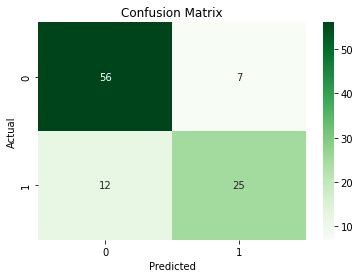

In [11]:
# Plot Confusion Matrix
sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")
# sns.heatmap(cm,annot=True)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


# sns.heatmap(cm, ...)
#     Creates a heatmap visualization of the confusion matrix
#     Converts numeric values into colored cells
#     Makes interpretation easier than plain numbers
# Internal Working
#     Takes the 2×2 matrix cm
#     Maps each value to a color intensity
#     Larger numbers → darker color
#     Smaller numbers → lighter color

# annot=True
#     Displays actual numeric values inside each cell

# fmt="d"
#     Formats numbers as integers
# Confusion matrix values are whole numbers